(60000, 28, 28)
학습셋 이미지 수 : 60000 개
테스트셋 이미지 수 : 10000 개


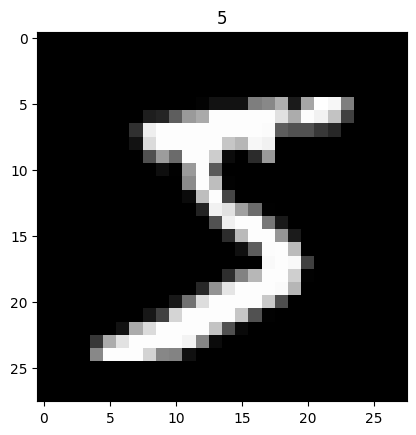

In [6]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

(X_train,y_train),(X_test,y_test) = mnist.load_data()

print(X_train.shape)

# 학습셋과 테스트셋이 각각 몇 개의 이미지로 되어 있는지 확인합니다. 
print("학습셋 이미지 수 : %d 개" % (X_train.shape[0]))
print("테스트셋 이미지 수 : %d 개" % (X_test.shape[0]))


plt.imshow(X_train[0],cmap="gray")
plt.title(y_train[0])
plt.show()

In [ ]:
# 이미지가 인식되는 원리를 알아봅시다.
import sys
# X_train[0]

# [
#  [0,0,0,...],
#  [0,0,0,...],
#  ...
# ]

# 첫 번째 행
# ↓

# 두 번째 행
# ↓

# 세 번째 행
# ↓

# ...

# 28번째 행  
for x in X_train[0]:
    for i in x:
        sys.stdout.write("%-3s" % i) # 첫번째행 오른쪽 3자리수 맞추어서 출력
    sys.stdout.write('\n')

0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  3  18 18 18 12613617526 1662552471270  0  0  0  
0  0  0  0  0  0  0  0  30 36 94 15417025325325325325322517225324219564 0  0  0  0  
0  0  0  0  0  0  0  49 23825325325325325325325325325193 82 82 56 39 0  0  0  0  0  
0  0  0  0  0  0  0  18 2192532532532532531981822472410  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  80 15610725325320511 0  43 1540  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  14 1  15425390 0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  1392531902  0  0  0  0  0  0  0 

정확도 : 0.2303


| 모델                  | 입력 형태     |   예상 정확도 |
| ------------------- | --------- | -------: |
| 선형회귀                | 784개 픽셀   |   25~40% |
| Logistic Regression | 784개 픽셀   |    약 92% |
| ANN (MLP)           | 784개 픽셀   | 약 97~98% |
| CNN                 | 28×28 이미지 |    약 99% |


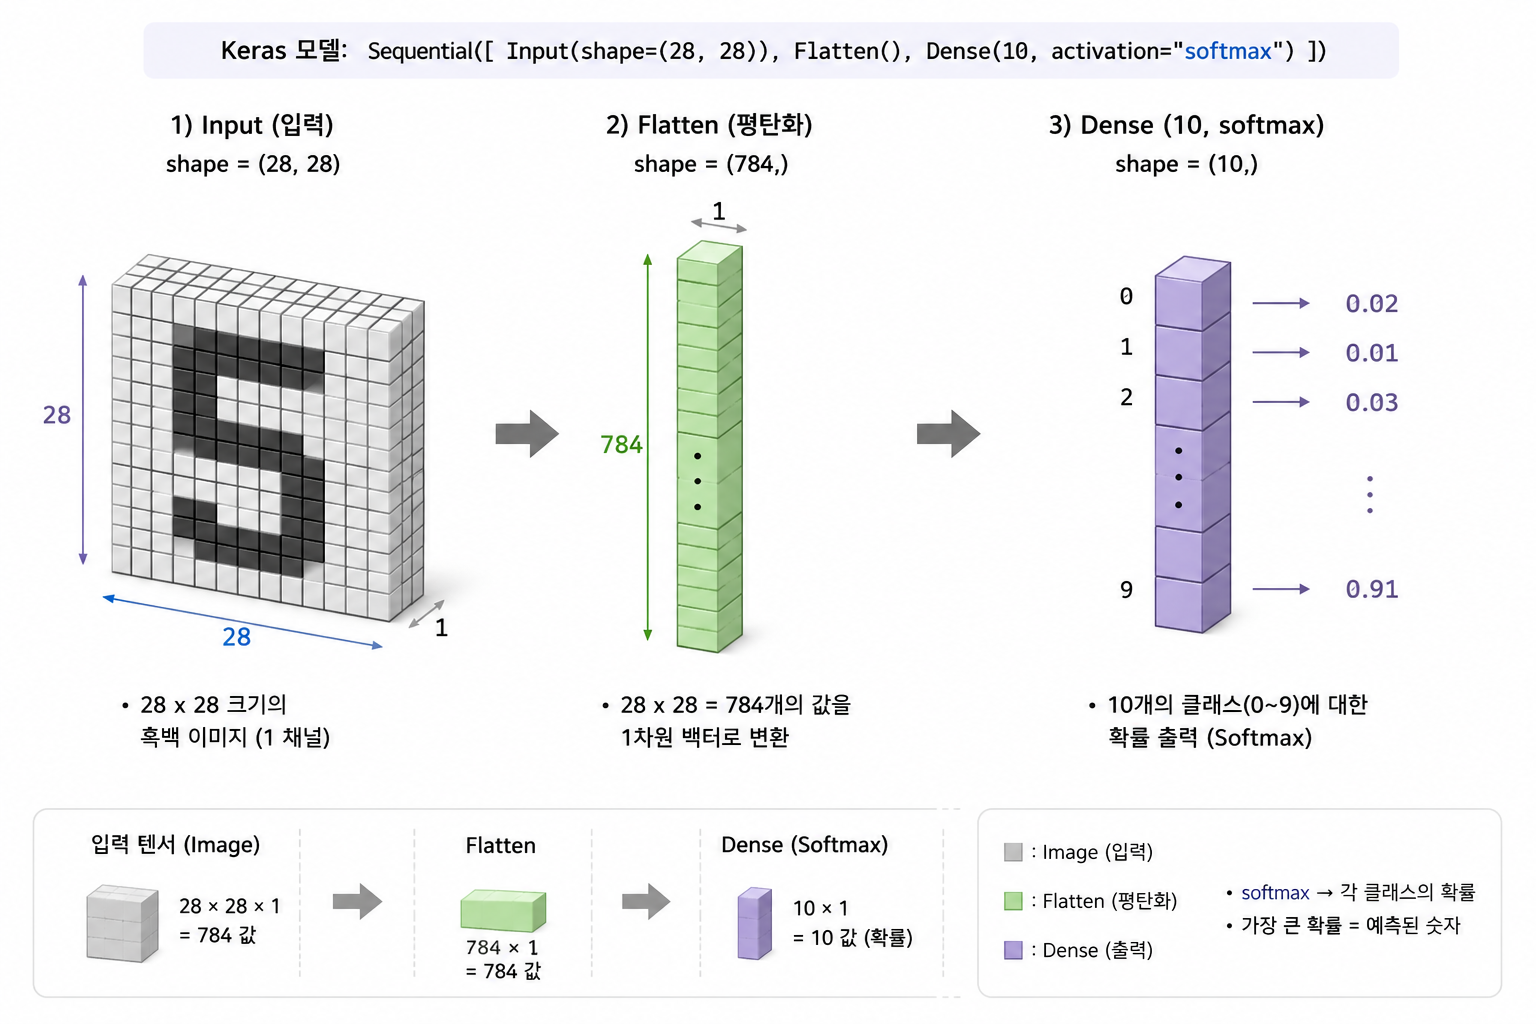

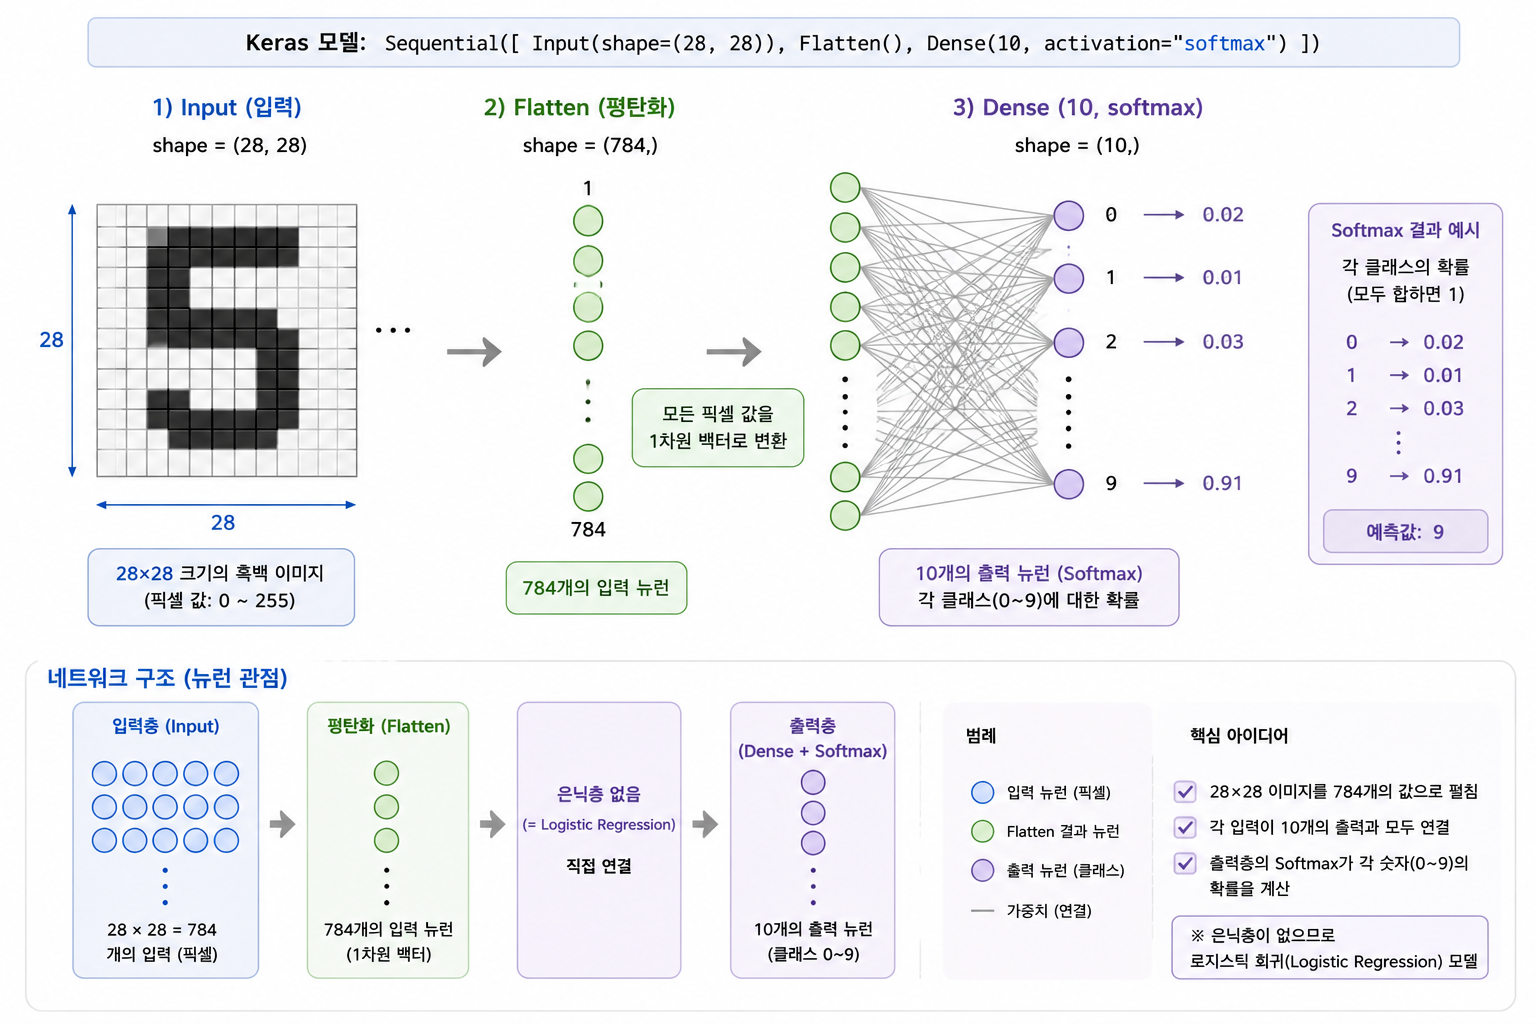

In [14]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense

# 데이터
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 정규화
# 예를 들어 키와 몸무게를 학습한다고 생각해 보겠습니다.
# 키 : 170
# 몸무게 : 65
# 두 값의 크기가 크게 다름

X_train = X_train / 255.0   
X_test = X_test / 255.0

# Logistic Regression 모델
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(10, activation="softmax")
])

# 모델 확인
model.summary()

# 컴파일
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 학습
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# 평가
loss, acc = model.evaluate(X_test, y_test)

print("정확도 :", acc)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8676 - loss: 0.5095 - val_accuracy: 0.9141 - val_loss: 0.3172
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9119 - loss: 0.3177 - val_accuracy: 0.9167 - val_loss: 0.2923
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9177 - loss: 0.2932 - val_accuracy: 0.9223 - val_loss: 0.2782
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9210 - loss: 0.2813 - val_accuracy: 0.9232 - val_loss: 0.2740
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9230 - loss: 0.2742 - val_accuracy: 0.9277 - val_loss: 0.2656
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9246 - loss: 0.2684 - val_accuracy: 0.9283 - val_loss: 0.2634
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9256 - loss: 0.2643 - val_accuracy: 0.9302 - val_loss: 0.2614
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9272 - loss: 0.2606 - 

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    # 입력 이미지 (28 x 28 흑백)
    Input(shape=(28, 28, 1)),

    # 특징 추출
    Conv2D(filters=32, kernel_size=(3,3), activation="relu"),

    # 크기 축소
    MaxPooling2D(pool_size=(2,2)),

    # 1차원으로 변환
    Flatten(),

    # 완전연결층
    Dense(128, activation="relu"),

    # 출력층
    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)